etapa 3 - presupuesto q1000
prob. completar (sobres sueltos) : 0.9488
media sobres comprados           : 71.6088
media estampas (no exitosos)     : 98.9609
max sobres con q1000 (piso)      : 105
minimo teorico sin repetidos     : 15
max_sobres >= min_teorico?       : True
prob. completar (caja 104)       : 0.9468
prob. completar (mixta 104+2)   : 0.9544
conviene la caja?                : no


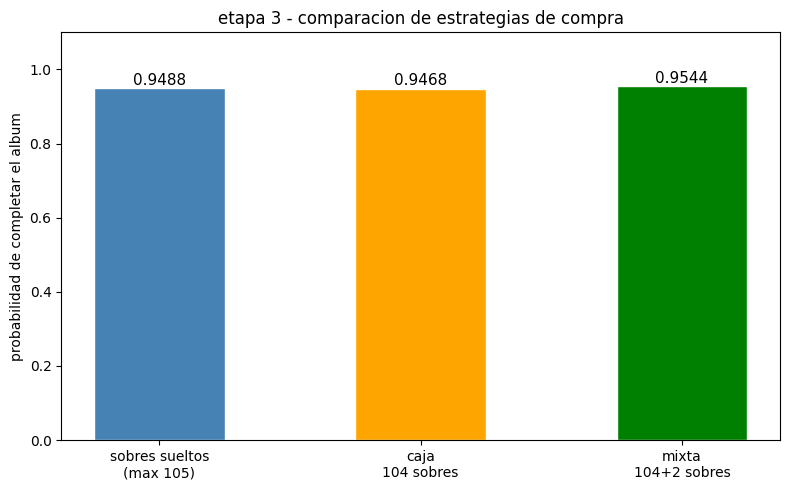


etapa 4 parte a - sobres hasta completar por k
   k     media       std    reduccion%
----------------------------------------
   1   15.0000    0.0000        79.24%
   2   19.8595    0.5203        72.51%
   5   28.1045    1.4535        61.10%
  10   35.1540    2.4216        51.34%


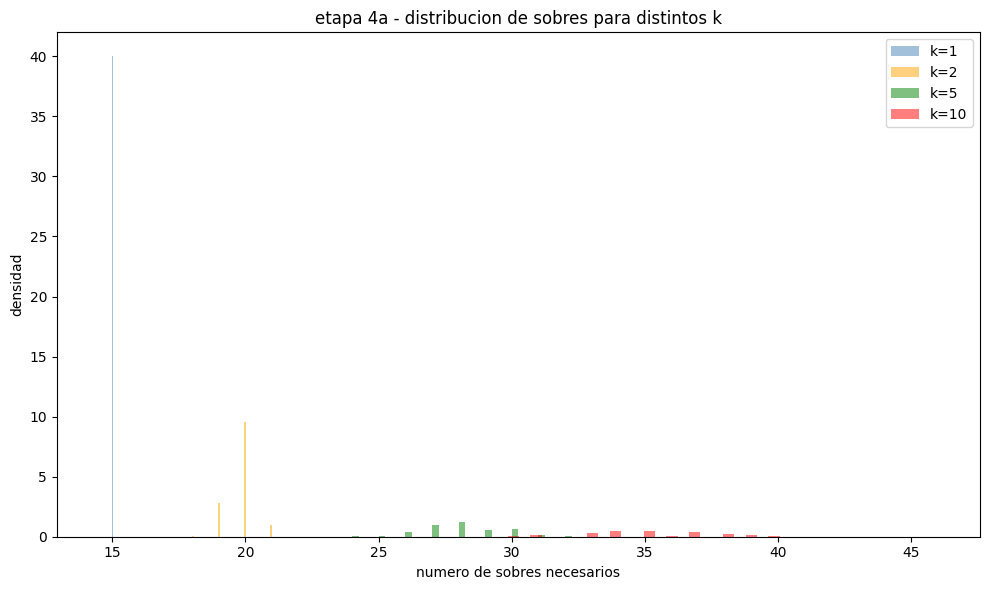


etapa 4 parte b - prob. exito vs m
   m  k=1  k=2  k=5  k=10  sin_int
----------------------------------------------------
  20    1.000  0.911  0.000  0.000  0.000
  25    1.000  1.000  0.017  0.000  0.000
  30    1.000  1.000  0.944  0.031  0.000
  35    1.000  1.000  1.000  0.627  0.000
  40    1.000  1.000  1.000  0.989  0.000
  45    1.000  1.000  1.000  1.000  0.000
  50    1.000  1.000  1.000  1.000  0.057
  55    1.000  1.000  1.000  1.000  0.180
  60    1.000  1.000  1.000  1.000  0.370
  65    1.000  1.000  1.000  1.000  0.534
  70    1.000  1.000  1.000  1.000  0.680

   k     50%     75%     90%
----------------------------
   1      20      20      20
   2      20      20      20
   5      30      30      30
  10      35      40      40


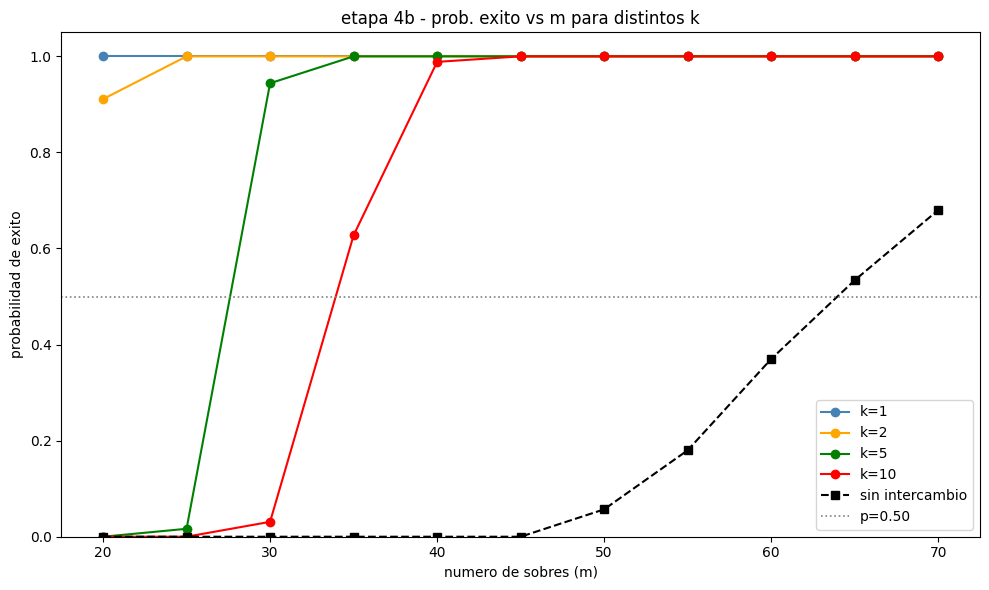


respuestas preguntas etapa 4
q2: k=2 ahorra 52.39 sobres en promedio = q497.71
q3: m=45 -> k=10:1.0000  k=5:1.0000  k=1:1.0000
    aumento k10->k5: 0.0000
    aumento k5->k1:  0.0000

q5: costo efectivo por estampa nueva via canje:
    k=1: q1.3571 por estampa
    k=2: q2.7143 por estampa
    k=5: q6.7857 por estampa
    k=10: q13.5714 por estampa


In [2]:
#Antony David Saz 24710
#Mariana castañeda 24481
# laboratorio 8 teoria de prob


import numpy as np
import matplotlib.pyplot as plt


# etapa 3 presupuesto y costo

np.random.seed(2026)
n = 100; s = 7; r = 10000; precio = 9.50; presupuesto = 1000

completados_e3 = []; sobres_e3 = []; estampas_inc = []
for _ in range(r):
    album = np.zeros(n, dtype=bool); gasto = 0; sob = 0
    while gasto + precio <= presupuesto and not album.all():
        album[np.random.choice(n, s, replace=False)] = True
        gasto += precio; sob += 1
    ok = album.all()
    completados_e3.append(int(ok)); sobres_e3.append(sob)
    if not ok: estampas_inc.append(album.sum())

prob_sueltos = np.mean(completados_e3)
media_sob_e3 = np.mean(sobres_e3)
media_inc = np.mean(estampas_inc) if estampas_inc else 0
max_sobres = int(presupuesto // precio)
min_teorico = int(np.ceil(n / s))


np.random.seed(2026)
comp_caja = []
for _ in range(r):
    album = np.zeros(n, dtype=bool)
    for _ in range(104):
        album[np.random.choice(n, s, replace=False)] = True
    comp_caja.append(int(album.all()))
prob_caja = np.mean(comp_caja)

# mixta, caja  sobres sueltos con sobrante
sobres_extra = int((presupuesto - 975) // precio)
np.random.seed(2026)
comp_mixto = []
for _ in range(r):
    album = np.zeros(n, dtype=bool)
    for _ in range(104 + sobres_extra):
        album[np.random.choice(n, s, replace=False)] = True
    comp_mixto.append(int(album.all()))
prob_mixto = np.mean(comp_mixto)

print("=" * 55)
print("etapa 3 - presupuesto q1000")
print("=" * 55)
print(f"prob. completar (sobres sueltos) : {prob_sueltos:.4f}")
print(f"media sobres comprados           : {media_sob_e3:.4f}")
print(f"media estampas (no exitosos)     : {media_inc:.4f}")
print(f"max sobres con q1000 (piso)      : {max_sobres}")
print(f"minimo teorico sin repetidos     : {min_teorico}")
print(f"max_sobres >= min_teorico?       : {max_sobres >= min_teorico}")
print(f"prob. completar (caja 104)       : {prob_caja:.4f}")
print(f"prob. completar (mixta 104+{sobres_extra})   : {prob_mixto:.4f}")
print(f"conviene la caja?                : {'si' if prob_caja > prob_sueltos else 'no'}")

fig, ax = plt.subplots(figsize=(8, 5))
etiquetas = [f'sobres sueltos\n(max {max_sobres})', 'caja\n104 sobres', f'mixta\n104+{sobres_extra} sobres']
probs_e3 = [prob_sueltos, prob_caja, prob_mixto]
bars = ax.bar(etiquetas, probs_e3, color=['steelblue', 'orange', 'green'], edgecolor='white', width=0.5)
for bar, p in zip(bars, probs_e3):
    ax.text(bar.get_x() + bar.get_width()/2, p + 0.01, f'{p:.4f}', ha='center', fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('probabilidad de completar el album')
ax.set_title('etapa 3 - comparacion de estrategias de compra')
plt.tight_layout()
plt.savefig('etapa3_barras.png', dpi=150)
plt.show()
plt.close()



# etapa 4 intercambio de repetidas
r_sim = 2000
k_valores = [1, 2, 5, 10]
base_media = 72.25
colors_h = ['steelblue', 'orange', 'green', 'red']

def sim_hasta_completar(n, s, k, r_sims, seed=2026):
    np.random.seed(seed)
    out = []
    for _ in range(r_sims):
        album = set(); rep = 0; sob = 0
        while len(album) < n:
            nuevas = np.random.choice(n, s, replace=False); sob += 1
            for e in nuevas:
                if e in album: rep += 1
                else: album.add(e)
            while rep >= k and len(album) < n:
                f = list(set(range(n)) - album)
                if f: album.add(np.random.choice(f)); rep -= k
        out.append(sob)
    return np.array(out)

def prob_m_sobres(n, s, k, m, r_sims, seed=2026):
    np.random.seed(seed)
    exitos = 0
    for _ in range(r_sims):
        album = set(); rep = 0
        for _ in range(m):
            nuevas = np.random.choice(n, s, replace=False)
            for e in nuevas:
                if e in album: rep += 1
                else: album.add(e)
            while rep >= k and len(album) < n:
                f = list(set(range(n)) - album)
                if f: album.add(np.random.choice(f)); rep -= k
        if len(album) == n: exitos += 1
    return exitos / r_sims

# parte a
print("\n" + "=" * 55)
print("etapa 4 parte a - sobres hasta completar por k")
print("=" * 55)
print(f"{'k':>4}  {'media':>8}  {'std':>8}  {'reduccion%':>12}")
print("-" * 40)

resultados_k = {}
for k in k_valores:
    datos = sim_hasta_completar(n, s, k, r_sim)
    resultados_k[k] = datos
    red = (base_media - datos.mean()) / base_media * 100
    print(f"{k:>4}  {datos.mean():>8.4f}  {datos.std():>8.4f}  {red:>11.2f}%")

fig, ax = plt.subplots(figsize=(10, 6))
for i, k in enumerate(k_valores):
    ax.hist(resultados_k[k], bins=40, alpha=0.5, density=True, label=f'k={k}', color=colors_h[i])
ax.set_xlabel('numero de sobres necesarios')
ax.set_ylabel('densidad')
ax.set_title('etapa 4a - distribucion de sobres para distintos k')
ax.legend()
plt.tight_layout()
plt.savefig('etapa4a_histogramas.png', dpi=150)
plt.show()
plt.close()


# parte b
m_valores = [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]
prob_sin_ref = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.057, 0.18, 0.37, 0.534, 0.68]

print("\n" + "=" * 55)
print("etapa 4 parte b - prob. exito vs m")
print("=" * 55)

resultados_b = {k: [] for k in k_valores}
header = f"{'m':>4}  " + "  ".join(f"k={k}" for k in k_valores) + "  sin_int"
print(header)
print("-" * 52)

for j, m in enumerate(m_valores):
    row = f"{m:>4}  "
    for k in k_valores:
        p = prob_m_sobres(n, s, k, m, r_sim)
        resultados_b[k].append(p)
        row += f"  {p:.3f}"
    row += f"  {prob_sin_ref[j]:.3f}"
    print(row)

# umbrales
print(f"\n{'k':>4}  {'50%':>6}  {'75%':>6}  {'90%':>6}")
print("-" * 28)
for k in k_valores:
    probs = resultados_b[k]
    m50=m75=m90='n/a'
    for j, p in enumerate(probs):
        if m50 == 'n/a' and p >= 0.50: m50 = m_valores[j]
        if m75 == 'n/a' and p >= 0.75: m75 = m_valores[j]
        if m90 == 'n/a' and p >= 0.90: m90 = m_valores[j]
    print(f"{k:>4}  {str(m50):>6}  {str(m75):>6}  {str(m90):>6}")


fig, ax = plt.subplots(figsize=(10, 6))
for i, k in enumerate(k_valores):
    ax.plot(m_valores, resultados_b[k], marker='o', label=f'k={k}', color=colors_h[i])
ax.plot(m_valores, prob_sin_ref, marker='s', linestyle='--', color='black', label='sin intercambio')
ax.axhline(0.5, color='gray', linestyle=':', lw=1.2, label='p=0.50')
ax.set_xlabel('numero de sobres (m)')
ax.set_ylabel('probabilidad de exito')
ax.set_title('etapa 4b - prob. exito vs m para distintos k')
ax.legend(); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('etapa4b_lineas.png', dpi=150)
plt.show()
plt.close()


# preguntas
print("\n" + "=" * 55)
print("respuestas preguntas etapa 4")
print("=" * 55)
media_k2 = resultados_k[2].mean()
ahorro = base_media - media_k2
print(f"q2: k=2 ahorra {ahorro:.2f} sobres en promedio = q{ahorro*precio:.2f}")

idx45 = m_valores.index(45)
p_k10 = resultados_b[10][idx45]; p_k5 = resultados_b[5][idx45]; p_k1 = resultados_b[1][idx45]
print(f"q3: m=45 -> k=10:{p_k10:.4f}  k=5:{p_k5:.4f}  k=1:{p_k1:.4f}")
print(f"    aumento k10->k5: {p_k5-p_k10:.4f}")
print(f"    aumento k5->k1:  {p_k1-p_k5:.4f}")

print(f"\nq5: costo efectivo por estampa nueva via canje:")
for k in k_valores:
    print(f"    k={k}: q{k * precio/s:.4f} por estampa")
